In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# import nessecory lib.

In [3]:
# loding the dataset 
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
fulfilment = pd.read_csv('fulfilment_center_info.csv')
meal = pd.read_csv('meal_info.csv')

In [4]:
train_merged = train.merge(fulfilment, on = 'center_id', how = 'left')  # merge the dataset train and fulfilment 
train_merged = train_merged.merge(meal, on = 'meal_id', how = 'left')   # merge the dataset train_merged and meal

test_merged = test.merge(fulfilment, on = 'center_id', how = 'left')    # same as training data merge test data
test_merged = test_merged.merge(meal, on = 'meal_id', how = 'left')

In [5]:
train_merged.to_csv('train_merged.csv', index = False)  # save the copy of merged datdasets
test_merged.to_csv('test_merged.csv', index = False)

In [6]:
print(train_merged.isna().sum())
print(f'\nduplicated values : {train_merged.duplicated().sum()}')

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64

duplicated values : 0


In [7]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian


In [8]:
wk = train_merged.groupby("week", as_index=False)["num_orders"].sum()

In [9]:
wk

,week,num_orders
0,1,792261
1,2,787084
2,3,695262
3,4,743529
4,5,1198675
...,...,...
140,141,776240
141,142,739661
142,143,759926
143,144,801197


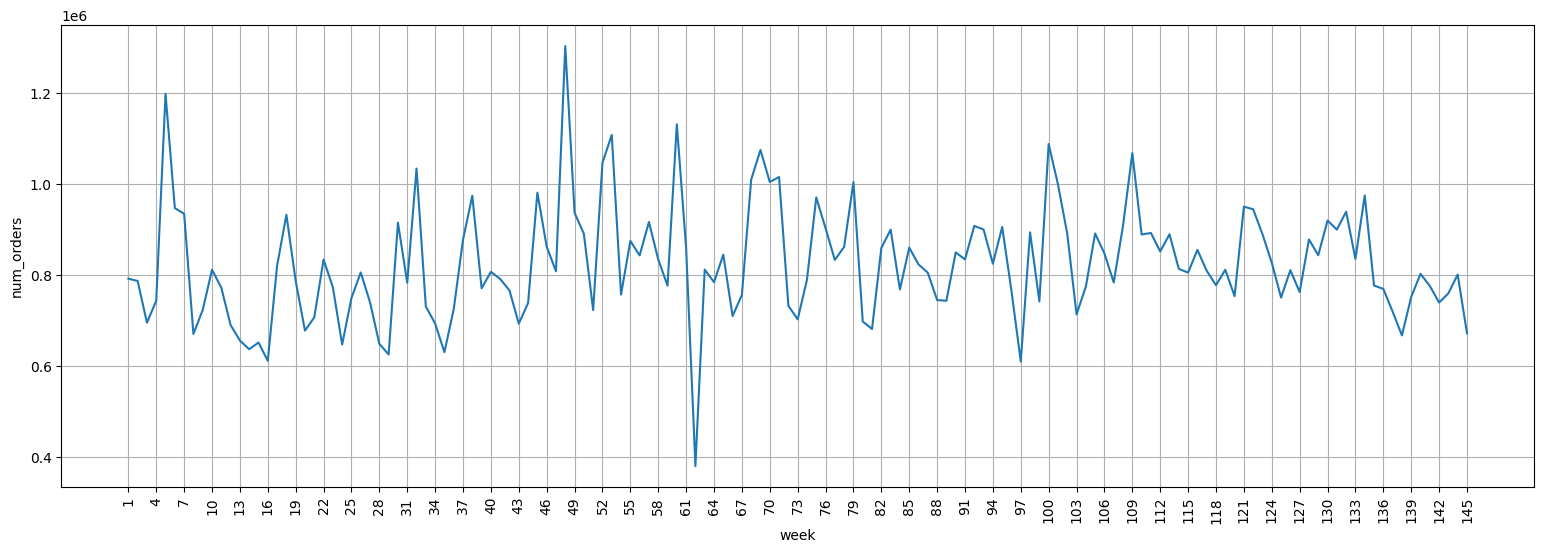

In [10]:
plt.figure(figsize=(19, 6))
sns.lineplot(wk, y = 'num_orders', x = 'week', markers = 'o')
plt.xticks(wk['week'][::3], rotation = 90)
plt.grid()
plt.show()

In [11]:
train_merged['discount'] = train_merged['base_price'] - train_merged['checkout_price']

In [12]:
train_merged['discount'] = train_merged['discount'].round(2)

In [13]:
train_merged.sort_values(by ='discount' ,ascending=False)

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount
108288,1419554,37,102,2444,145.53,707.13,0,0,54,593,77,TYPE_A,2.8,Seafood,Continental,561.60
287522,1176573,94,92,2444,163.93,708.13,1,0,15,526,34,TYPE_C,2.9,Seafood,Continental,544.20
258834,1000988,85,161,2304,226.04,736.23,0,0,69,658,34,TYPE_B,3.9,Desert,Indian,510.19
111288,1192242,38,102,2444,243.50,708.13,0,0,15,593,77,TYPE_A,2.8,Seafood,Continental,464.63
262090,1181537,86,161,2304,338.59,736.23,1,1,134,658,34,TYPE_B,3.9,Desert,Indian,397.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331761,1332869,107,23,1230,497.61,325.01,0,1,42,698,23,TYPE_A,3.4,Beverages,Continental,-172.60
327056,1290542,106,153,2322,496.64,322.10,0,1,41,590,56,TYPE_A,3.9,Beverages,Continental,-174.54
331762,1056437,107,23,2322,503.49,324.01,0,1,13,698,23,TYPE_A,3.4,Beverages,Continental,-179.48
328498,1238282,106,23,2322,508.31,324.01,0,1,121,698,23,TYPE_A,3.4,Beverages,Continental,-184.30


In [14]:
train_merged["discount_per"] = (((train_merged["base_price"] - train_merged["checkout_price"])/ train_merged["base_price"]) * 100).round(2)

In [15]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


In [16]:
train_merged.sort_values(by ='discount_per' ,ascending=False)

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
110286,1300283,38,73,1230,2.97,316.25,0,0,14,576,34,TYPE_A,4.0,Beverages,Continental,313.28,99.06
173526,1017697,58,102,1109,56.26,319.13,0,0,229,593,77,TYPE_A,2.8,Rice Bowl,Indian,262.87,82.37
44875,1381921,16,41,1248,45.62,253.23,0,0,123,590,56,TYPE_C,1.9,Beverages,Indian,207.61,81.98
44874,1414392,16,41,2631,47.59,253.23,0,0,163,590,56,TYPE_C,1.9,Beverages,Indian,205.64,81.21
224346,1472105,74,80,1198,65.02,319.13,0,0,69,604,56,TYPE_C,5.1,Extras,Thai,254.11,79.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328497,1406829,106,23,1230,509.31,324.01,0,1,107,698,23,TYPE_A,3.4,Beverages,Continental,-185.30,-57.19
442314,1267391,141,72,1248,163.93,98.03,0,1,27,638,56,TYPE_C,3.9,Beverages,Indian,-65.90,-67.22
442313,1288740,141,72,2631,163.93,98.03,0,1,69,638,56,TYPE_C,3.9,Beverages,Indian,-65.90,-67.22
445564,1228305,142,72,1248,163.02,97.03,0,1,80,638,56,TYPE_C,3.9,Beverages,Indian,-65.99,-68.01


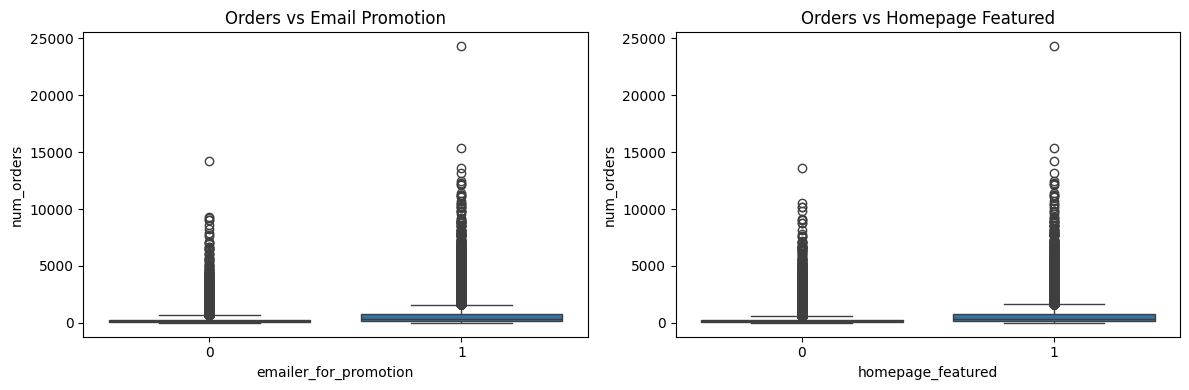

In [17]:

fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.boxplot(data=train_merged, x="emailer_for_promotion", y="num_orders", ax=ax[0])
ax[0].set_title("Orders vs Email Promotion")

sns.boxplot(data=train_merged, x="homepage_featured", y="num_orders", ax=ax[1])
ax[1].set_title("Orders vs Homepage Featured")
plt.tight_layout()
plt.show()




In [18]:
train_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
 9   city_code              456548 non-null  int64  
 10  region_code            456548 non-null  int64  
 11  center_type            456548 non-null  object 
 12  op_area                456548 non-null  float64
 13  category               456548 non-null  object 
 14  cuisine                456548 non-nu

In [19]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


<Axes: >

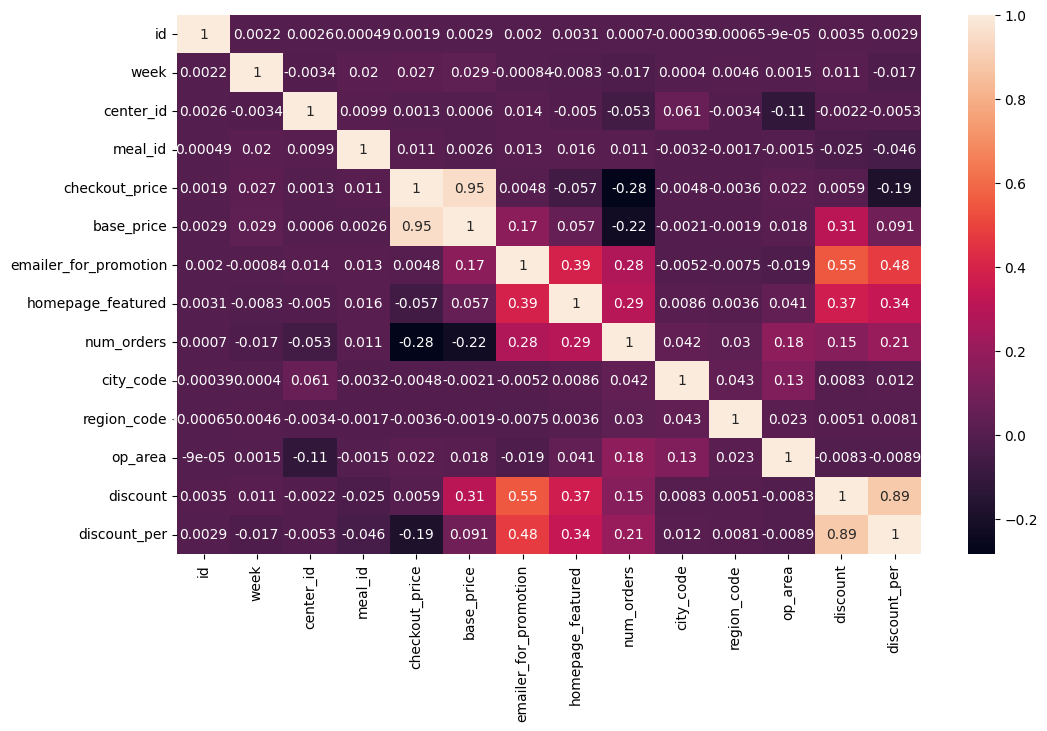

In [20]:
plt.figure(figsize=(12,7))
sns.heatmap(train_merged.corr(numeric_only=True), annot=True)

In [21]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


In [22]:
total_order_center = train_merged.groupby('center_id')['num_orders'].sum()

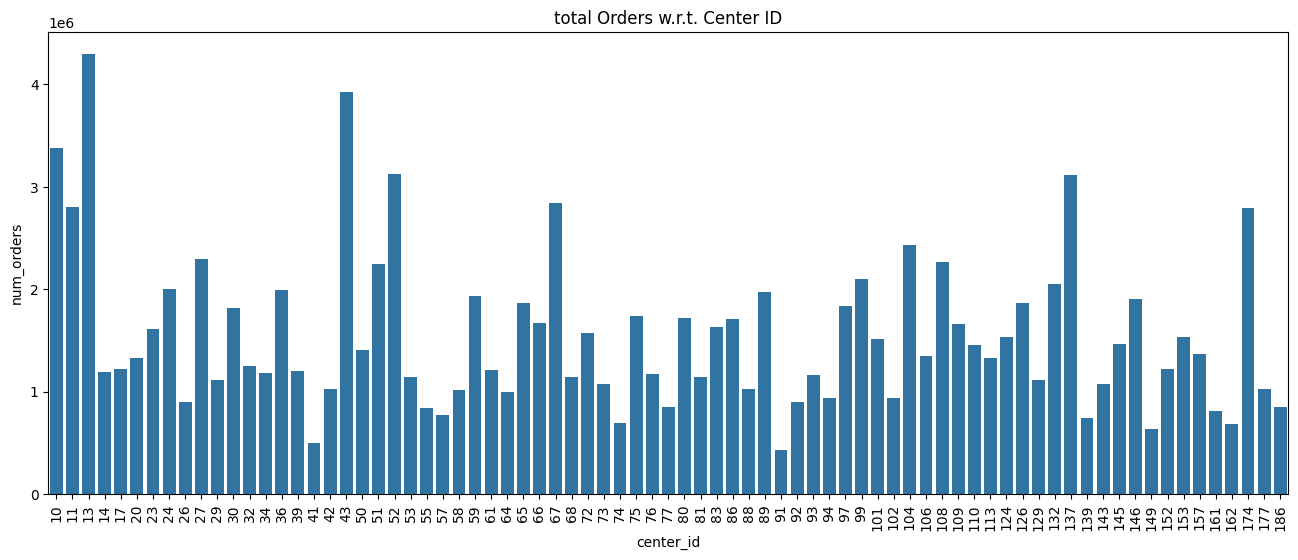

In [23]:
plt.figure(figsize = (16,6))
sns.barplot(total_order_center)
plt.xticks(rotation = 90)
plt.title('total Orders w.r.t. Center ID')
plt.show()

In [24]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


In [25]:
train_merged['center_type'].value_counts()

center_type
TYPE_A    262881
TYPE_C     99593
TYPE_B     94074
Name: count, dtype: int64

<Axes: xlabel='center_type', ylabel='num_orders'>

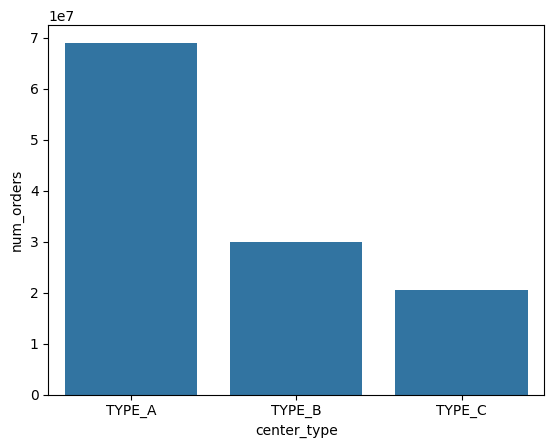

In [26]:
total_order_center_type = train_merged.groupby('center_type')['num_orders'].sum()
sns.barplot(total_order_center_type)

In [27]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


<Axes: xlabel='region_code', ylabel='num_orders'>

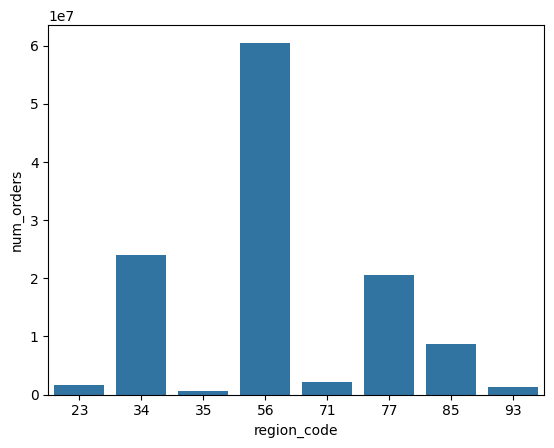

In [28]:
total_order_region = train_merged.groupby('region_code')['num_orders'].sum()

sns.barplot(total_order_region)

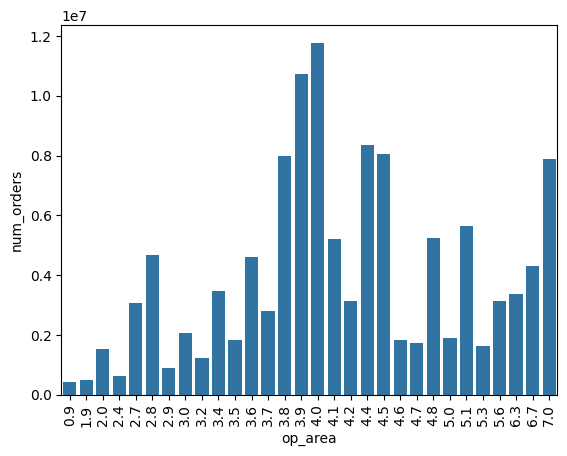

In [29]:
total_order_area = train_merged.groupby('op_area')['num_orders'].sum()

sns.barplot(total_order_area)
plt.xticks(rotation = 90)
plt.show()

In [30]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,-0.74
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,-0.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29


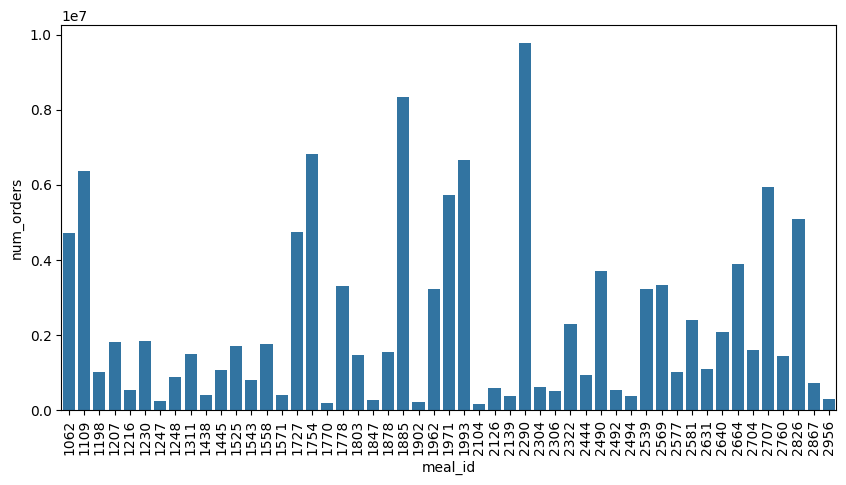

In [31]:
total_order_meal = train_merged.groupby('meal_id')['num_orders'].sum()
plt.figure(figsize=(10,5))
sns.barplot(total_order_meal)
plt.xticks(rotation = 90)
plt.show()

In [32]:
print(train_merged['cuisine'].value_counts())
print(train_merged['category'].value_counts())

cuisine
Italian        122925
Thai           118216
Indian         112612
Continental    102795
Name: count, dtype: int64
category
Beverages       127890
Rice Bowl        33408
Sandwich         33291
Pizza            33138
Starters         29941
Other Snacks     29379
Desert           29294
Salad            28559
Pasta            27694
Seafood          26916
Biryani          20614
Extras           13562
Soup             12675
Fish             10187
Name: count, dtype: int64


In [33]:


meal_week = (
    train_merged.groupby(["meal_id", "week"], as_index=False)["num_orders"]
    .sum()
    .sort_values(["meal_id", "week"])
)

# seasonal strength score per meal (higher = stronger repeating pattern)
seasonality = (
    meal_week.groupby("meal_id")["num_orders"]
    .apply(lambda s: s.autocorr(lag=52) if len(s) > 52 else np.nan)
    .reset_index(name="seasonality_score")
    .sort_values("seasonality_score", ascending=False)
)

seasonality.head(20)   # strongest seasonal meals


,meal_id,seasonality_score
20,1847,0.753204
32,2306,0.600986
37,2494,0.580460
9,1438,0.550967
19,1803,0.471212
36,2492,0.466017
15,1727,0.429894
22,1885,0.405325
26,1993,0.405049
5,1230,0.393160


In [34]:
train_merged.loc[train_merged["discount_per"] < 0, "discount_per"] = 0

In [35]:
disc_bins = [-0.01, 0, 5, 10, 20, 30, 40, 50, 100]
disc_labels = ["0%", "0-5%", "5-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50%+"]

train_merged["discount_bin"] = pd.cut(
    train_merged["discount_per"],
    bins=disc_bins,
    labels=disc_labels,
    include_lowest=True
)

# Demand vs discount bins
disc_summary = (
    train_merged.groupby("discount_bin", observed=False)["num_orders"]
    .agg(total_orders="sum", avg_orders="mean", count="count")
    .reset_index()
)
disc_summary

,discount_bin,total_orders,avg_orders,count
0,0%,49307770,217.346019,226863
1,0-5%,25265319,219.728997,114984
2,5-10%,1732646,372.932845,4646
3,10-20%,18021618,346.256614,52047
4,20-30%,10542801,353.963438,29785
5,30-40%,9625242,443.600424,21698
6,40-50%,4585552,1059.753178,4327
7,50%+,476537,216.804823,2198


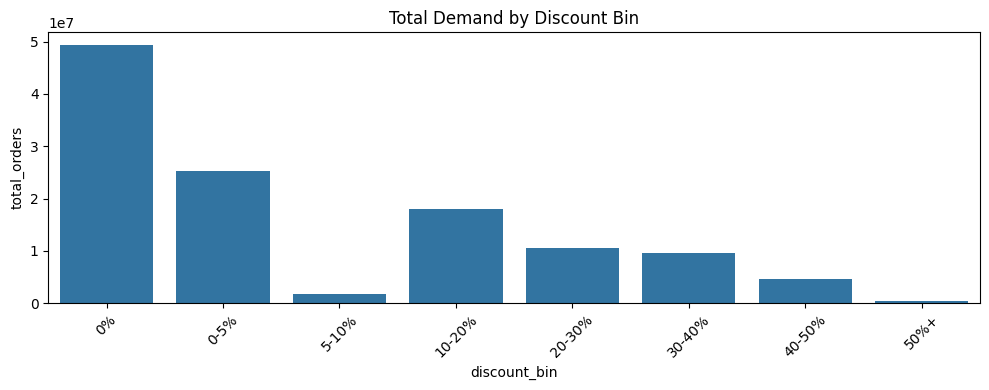

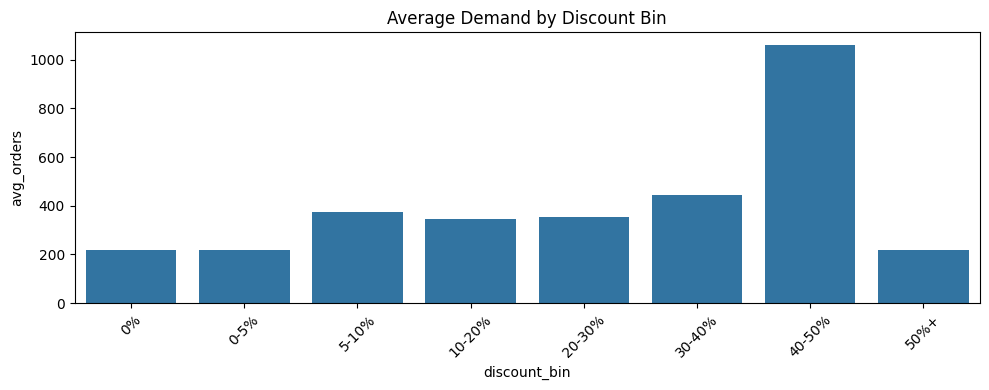

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.barplot(data=disc_summary, x="discount_bin", y="total_orders")
plt.title("Total Demand by Discount Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(data=disc_summary, x="discount_bin", y="avg_orders")
plt.title("Average Demand by Discount Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [37]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per,discount_bin
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15,10-20%
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,0.00,0%
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74,0-5%
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41,20-30%
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,0.00,0%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97,20-30%
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29,20-30%


In [38]:
price_bins = [0, 100, 150, 200, 250, 300, 400, 600, np.inf]
price_labels = ["<=100", "101-150", "151-200", "201-250", "251-300", "301-400", "401-600", "600+"]

train_merged["price_band"] = pd.cut(
    train_merged["checkout_price"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

price_summary = (
    train_merged.groupby("price_band", observed=False)["num_orders"]
    .agg(total_orders="sum", avg_orders="mean", count="count")
    .reset_index()
)
price_summary


,price_band,total_orders,avg_orders,count
0,<=100,3460572,293.592263,11787
1,101-150,15133121,506.531028,29876
2,151-200,25846781,419.542925,61607
3,201-250,16968062,339.762159,49941
4,251-300,21885341,279.806446,78216
5,301-400,19633391,223.187875,87968
6,401-600,13300279,136.004407,97793
7,600+,3329938,84.602083,39360


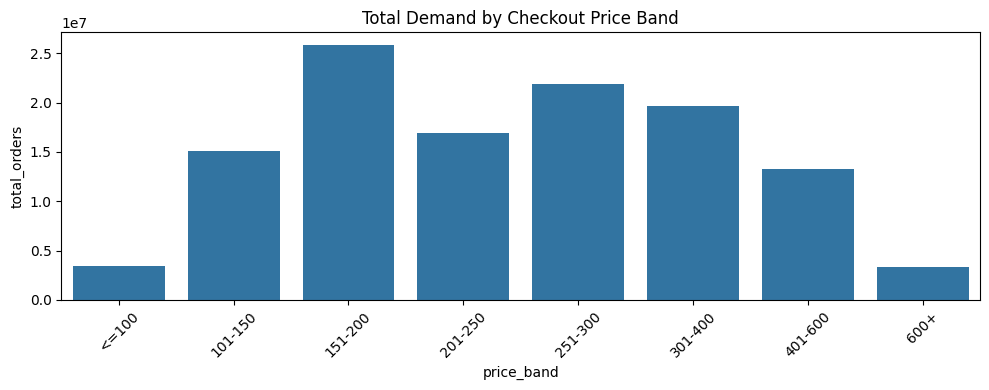

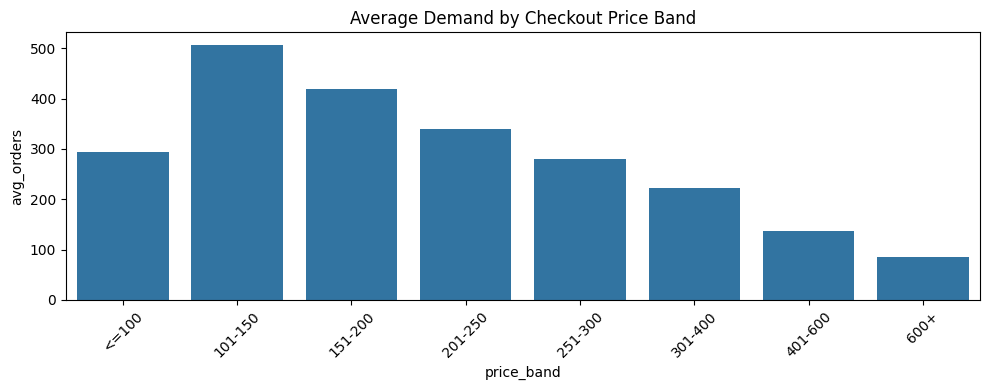

In [39]:
plt.figure(figsize=(10,4))
sns.barplot(data=price_summary, x="price_band", y="total_orders")
plt.title("Total Demand by Checkout Price Band")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(data=price_summary, x="price_band", y="avg_orders")
plt.title("Average Demand by Checkout Price Band")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [40]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per,discount_bin,price_band
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15,10-20%,101-150
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,0.00,0%,101-150
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74,0-5%,101-150
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41,20-30%,301-400
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,0.00,0%,201-250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%,401-600
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%,401-600
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97,20-30%,201-250
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29,20-30%,201-250


In [41]:
start_data = pd.Timestamp('2018-01-01')

train_merged['week_date'] = start_data + pd.to_timedelta((train_merged['week'] - 1) * 7, unit = 'D')

In [42]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per,discount_bin,price_band,week_date
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15,10-20%,101-150,2018-01-01
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,0.00,0%,101-150,2018-01-01
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74,0-5%,101-150,2018-01-01
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41,20-30%,301-400,2018-01-01
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,0.00,0%,201-250,2018-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%,401-600,2020-10-05
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%,401-600,2020-10-05
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97,20-30%,201-250,2020-10-05
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29,20-30%,201-250,2020-10-05


In [43]:
test_merged['week_date'] = start_data + pd.to_timedelta((test_merged['week'] - 1) * 7, unit = 'D')

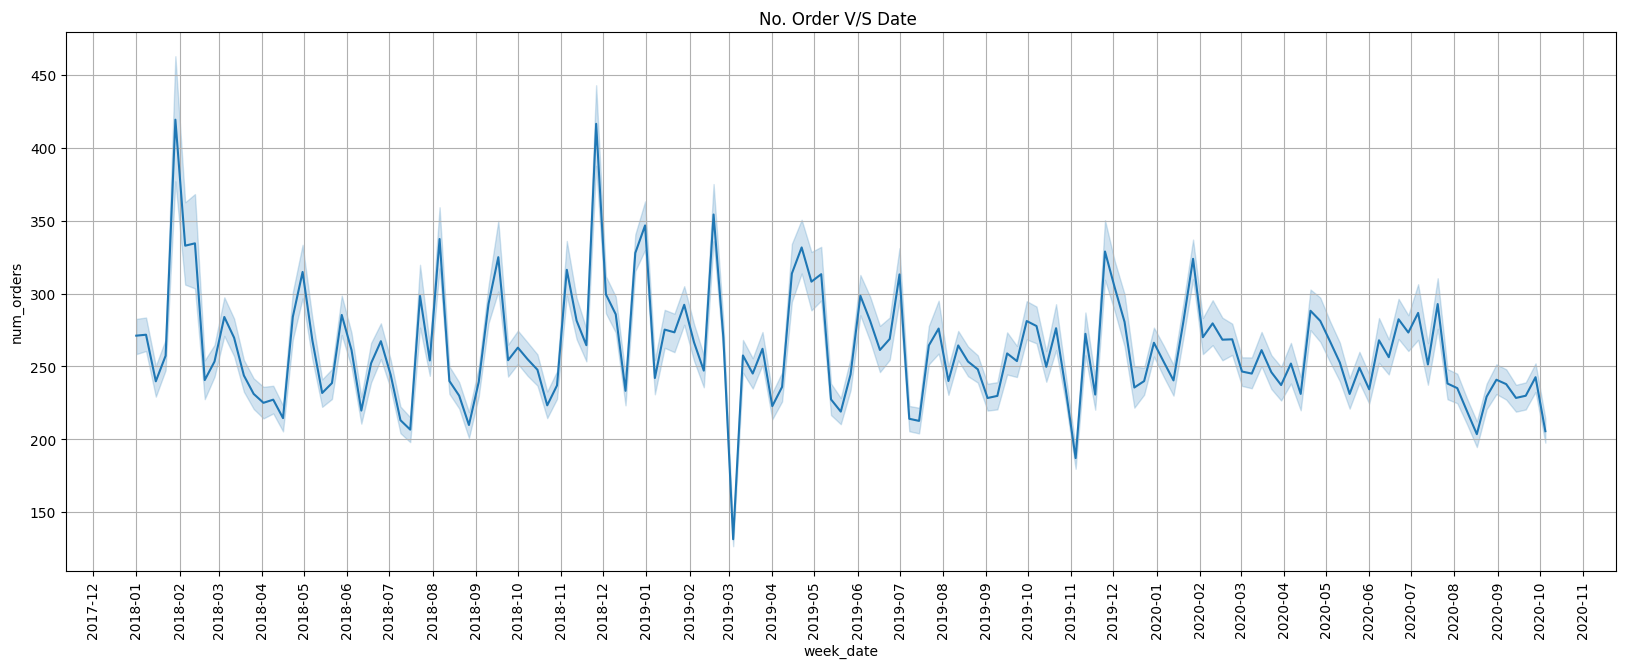

In [44]:
import matplotlib.dates as mdates
plt.figure(figsize=(20,7))
sns.lineplot(train_merged, x = 'week_date', y = 'num_orders')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation = 90)
plt.title('No. Order V/S Date ')
plt.grid()
plt.show()

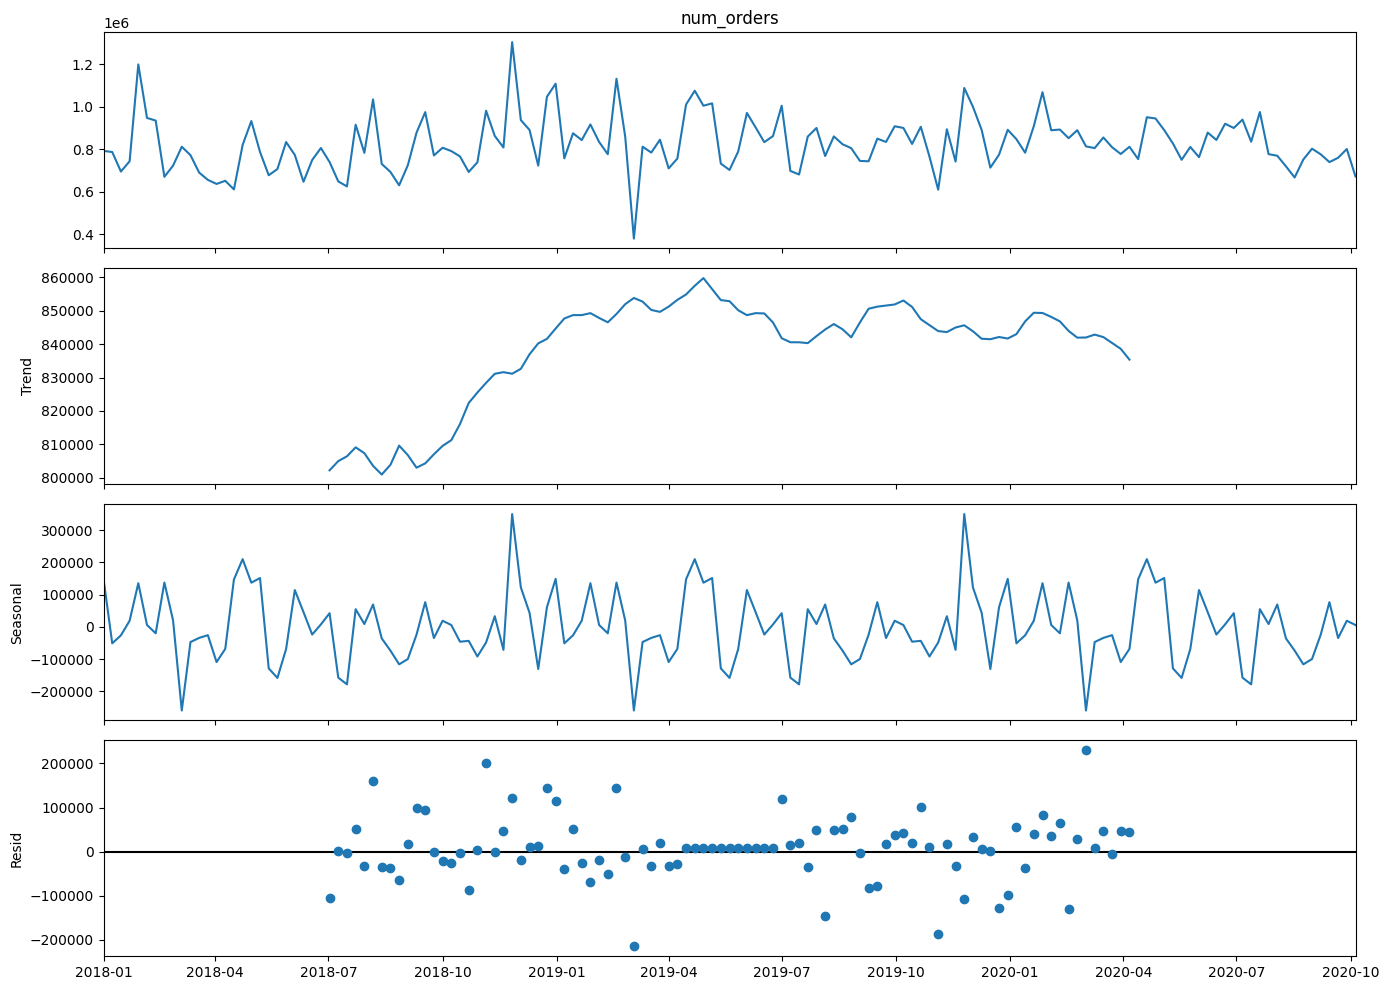

In [45]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = train_merged.groupby('week_date')['num_orders'].sum().sort_index()

result = seasonal_decompose(ts, ) # model = 'additive', period = 52
fit = result.plot()
fit.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

In [46]:
ts

week_date
2018-01-01     792261
2018-01-08     787084
2018-01-15     695262
2018-01-22     743529
2018-01-29    1198675
               ...   
2020-09-07     776240
2020-09-14     739661
2020-09-21     759926
2020-09-28     801197
2020-10-05     671926
Name: num_orders, Length: 145, dtype: int64

In [47]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


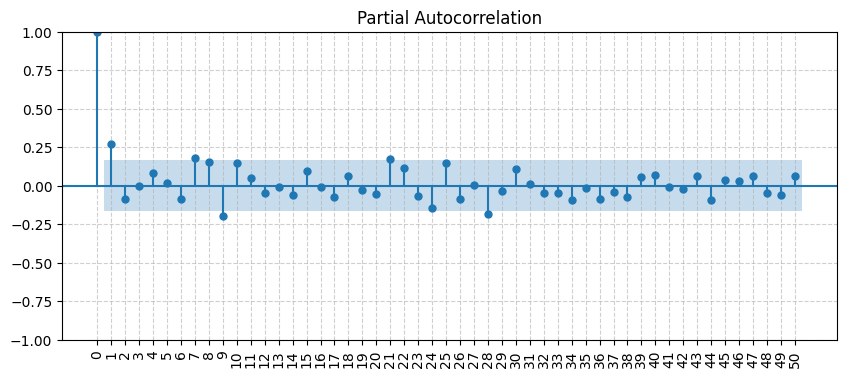

In [48]:
fig, ax = plt.subplots(figsize=(10,4))
plot_pacf(ts, lags=50, method="ywm", ax=ax)

ax.set_xticks(range(0, 51))   # one tick per lag
ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.6)
plt.xticks(rotation = 90)
plt.show()

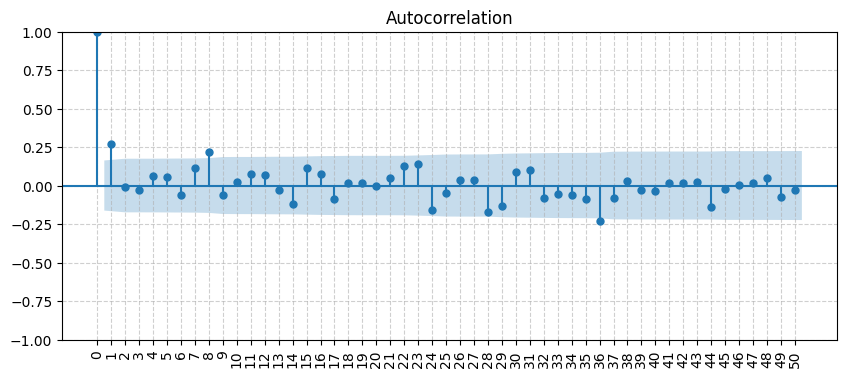

In [49]:
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(ts, lags=50, ax=ax)

ax.set_xticks(range(0, 51))   # one tick per lag
ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.6)
plt.xticks(rotation = 90)
plt.show()

In [50]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,discount,discount_per,discount_bin,price_band,week_date
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,15.46,10.15,10-20%,101-150,2018-01-01
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,-1.00,0.00,0%,101-150,2018-01-01
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,1.00,0.74,0-5%,101-150,2018-01-01
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,98.03,22.41,20-30%,301-400,2018-01-01
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,-1.00,0.00,0%,201-250,2018-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%,401-600,2020-10-05
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,TYPE_A,4.5,Desert,Indian,0.00,0.00,0%,401-600,2020-10-05
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,TYPE_A,4.5,Salad,Italian,83.39,25.97,20-30%,201-250,2020-10-05
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,TYPE_A,4.5,Salad,Italian,69.84,22.29,20-30%,201-250,2020-10-05


In [51]:
train_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id                     456548 non-null  int64         
 1   week                   456548 non-null  int64         
 2   center_id              456548 non-null  int64         
 3   meal_id                456548 non-null  int64         
 4   checkout_price         456548 non-null  float64       
 5   base_price             456548 non-null  float64       
 6   emailer_for_promotion  456548 non-null  int64         
 7   homepage_featured      456548 non-null  int64         
 8   num_orders             456548 non-null  int64         
 9   city_code              456548 non-null  int64         
 10  region_code            456548 non-null  int64         
 11  center_type            456548 non-null  object        
 12  op_area                456548 non-null  floa

In [52]:
train_merged['id'].name

'id'

In [53]:
for i in train_merged.columns:
    if train_merged[i].dtype not in ['int64' , 'float64']:
        print(f'{train_merged[i].name} : {train_merged[i].nunique()}')

center_type : 3
category : 14
cuisine : 4
discount_bin : 8
price_band : 8
week_date : 145


In [54]:
cat_col = ['center_type', 'category', 'cuisine', 'discount_bin', 'price_band']

In [55]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False,               # for readable
                        handle_unknown='ignore'     # dont crash for unknown data
                        )

In [56]:
import joblib

joblib.dump(encoder, 'encoder.pkl')

['encoder.pkl']

In [57]:
encoder.fit(train_merged[cat_col])

encoded = encoder.transform(train_merged[cat_col])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_col))

In [58]:
encoded_df

,center_type_TYPE_A,center_type_TYPE_B,center_type_TYPE_C,category_Beverages,category_Biryani,category_Desert,category_Extras,category_Fish,category_Other Snacks,category_Pasta,category_Pizza,category_Rice Bowl,category_Salad,category_Sandwich,category_Seafood,category_Soup,category_Starters,cuisine_Continental,cuisine_Indian,cuisine_Italian,cuisine_Thai,discount_bin_0%,discount_bin_0-5%,discount_bin_10-20%,discount_bin_20-30%,discount_bin_30-40%,discount_bin_40-50%,discount_bin_5-10%,discount_bin_50%+,price_band_101-150,price_band_151-200,price_band_201-250,price_band_251-300,price_band_301-400,price_band_401-600,price_band_600+,price_band_<=100
0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
456544,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
456545,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
456546,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [59]:
encoded_df.index = train_merged.index

In [60]:
train_merged = pd.concat([train_merged.drop(columns=(cat_col)), encoded_df],axis=1)

In [61]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area,discount,discount_per,week_date,center_type_TYPE_A,center_type_TYPE_B,center_type_TYPE_C,category_Beverages,category_Biryani,category_Desert,category_Extras,category_Fish,category_Other Snacks,category_Pasta,category_Pizza,category_Rice Bowl,category_Salad,category_Sandwich,category_Seafood,category_Soup,category_Starters,cuisine_Continental,cuisine_Indian,cuisine_Italian,cuisine_Thai,discount_bin_0%,discount_bin_0-5%,discount_bin_10-20%,discount_bin_20-30%,discount_bin_30-40%,discount_bin_40-50%,discount_bin_5-10%,discount_bin_50%+,price_band_101-150,price_band_151-200,price_band_201-250,price_band_251-300,price_band_301-400,price_band_401-600,price_band_600+,price_band_<=100
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,2.0,15.46,10.15,2018-01-01,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,2.0,-1.00,0.00,2018-01-01,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,2.0,1.00,0.74,2018-01-01,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,2.0,98.03,22.41,2018-01-01,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,2.0,-1.00,0.00,2018-01-01,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,4.5,0.00,0.00,2020-10-05,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,4.5,0.00,0.00,2020-10-05,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,4.5,83.39,25.97,2020-10-05,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,4.5,69.84,22.29,2020-10-05,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [62]:
print(train_merged.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 52 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id                     456548 non-null  int64         
 1   week                   456548 non-null  int64         
 2   center_id              456548 non-null  int64         
 3   meal_id                456548 non-null  int64         
 4   checkout_price         456548 non-null  float64       
 5   base_price             456548 non-null  float64       
 6   emailer_for_promotion  456548 non-null  int64         
 7   homepage_featured      456548 non-null  int64         
 8   num_orders             456548 non-null  int64         
 9   city_code              456548 non-null  int64         
 10  region_code            456548 non-null  int64         
 11  op_area                456548 non-null  float64       
 12  discount               456548 non-null  floa

In [ ]:
from sklearn.model_selection import train_test_split
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area,discount,discount_per,week_date,center_type_TYPE_A,center_type_TYPE_B,center_type_TYPE_C,category_Beverages,category_Biryani,category_Desert,category_Extras,category_Fish,category_Other Snacks,category_Pasta,category_Pizza,category_Rice Bowl,category_Salad,category_Sandwich,category_Seafood,category_Soup,category_Starters,cuisine_Continental,cuisine_Indian,cuisine_Italian,cuisine_Thai,discount_bin_0%,discount_bin_0-5%,discount_bin_10-20%,discount_bin_20-30%,discount_bin_30-40%,discount_bin_40-50%,discount_bin_5-10%,discount_bin_50%+,price_band_101-150,price_band_151-200,price_band_201-250,price_band_251-300,price_band_301-400,price_band_401-600,price_band_600+,price_band_<=100
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,2.0,15.46,10.15,2018-01-01,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,2.0,-1.00,0.00,2018-01-01,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,2.0,1.00,0.74,2018-01-01,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,2.0,98.03,22.41,2018-01-01,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,2.0,-1.00,0.00,2018-01-01,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456543,1271326,145,61,1543,484.09,484.09,0,0,68,473,77,4.5,0.00,0.00,2020-10-05,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
456544,1062036,145,61,2304,482.09,482.09,0,0,42,473,77,4.5,0.00,0.00,2020-10-05,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
456545,1110849,145,61,2664,237.68,321.07,0,0,501,473,77,4.5,83.39,25.97,2020-10-05,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
456546,1147725,145,61,2569,243.50,313.34,0,0,729,473,77,4.5,69.84,22.29,2020-10-05,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [64]:
week_date = train_merged['week_date']
train_merged.drop(columns=['week_date'], inplace=True)

In [ ]:
# X = train_merged.drop(columns=['num_orders'])
# y = train_merged['num_orders']

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 23, test_size=.25)

In [73]:
train_merged = train_merged.sort_values(['center_id', 'meal_id', 'week'])

In [74]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area,discount,discount_per,center_type_TYPE_A,center_type_TYPE_B,center_type_TYPE_C,category_Beverages,category_Biryani,category_Desert,category_Extras,category_Fish,category_Other Snacks,category_Pasta,category_Pizza,category_Rice Bowl,category_Salad,category_Sandwich,category_Seafood,category_Soup,category_Starters,cuisine_Continental,cuisine_Indian,cuisine_Italian,cuisine_Thai,discount_bin_0%,discount_bin_0-5%,discount_bin_10-20%,discount_bin_20-30%,discount_bin_30-40%,discount_bin_40-50%,discount_bin_5-10%,discount_bin_50%+,price_band_101-150,price_band_151-200,price_band_201-250,price_band_251-300,price_band_301-400,price_band_401-600,price_band_600+,price_band_<=100
2370,1436842,1,10,1062,181.39,181.39,0,0,865,590,56,6.3,0.0,0.00,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5273,1205013,2,10,1062,183.36,182.36,0,0,782,590,56,6.3,-1.0,0.00,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8175,1447751,3,10,1062,184.36,182.36,0,0,851,590,56,6.3,-2.0,0.00,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
11064,1014968,4,10,1062,182.36,183.36,0,0,1202,590,56,6.3,1.0,0.55,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
13918,1003563,5,10,1062,183.39,181.39,0,0,958,590,56,6.3,-2.0,0.00,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345410,1255251,112,186,2956,583.03,581.03,0,0,82,649,34,3.4,-2.0,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
348601,1436164,113,186,2956,583.03,582.03,0,0,40,649,34,3.4,-1.0,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
351905,1000576,114,186,2956,583.03,581.03,0,0,27,649,34,3.4,-2.0,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
355206,1429037,115,186,2956,581.03,583.03,0,0,15,649,34,3.4,2.0,0.34,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [80]:
train_merged['lag_1'] = train_merged.groupby(['center_id', 'meal_id'])['num_orders'].shift(1)
train_merged['lag_2'] = train_merged.groupby(['center_id', 'meal_id'])['num_orders'].shift(2)
train_merged['lag_3'] = train_merged.groupby(['center_id', 'meal_id'])['num_orders'].shift(3)
train_merged['rolling_mean_4'] = train_merged.groupby(['center_id', 'meal_id'])['num_orders'].transform(lambda x: x.shift(1).rolling(4).mean())

In [81]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area,discount,discount_per,center_type_TYPE_A,center_type_TYPE_B,center_type_TYPE_C,category_Beverages,category_Biryani,category_Desert,category_Extras,category_Fish,category_Other Snacks,category_Pasta,category_Pizza,category_Rice Bowl,category_Salad,category_Sandwich,category_Seafood,category_Soup,category_Starters,cuisine_Continental,cuisine_Indian,cuisine_Italian,cuisine_Thai,discount_bin_0%,discount_bin_0-5%,discount_bin_10-20%,discount_bin_20-30%,discount_bin_30-40%,discount_bin_40-50%,discount_bin_5-10%,discount_bin_50%+,price_band_101-150,price_band_151-200,price_band_201-250,price_band_251-300,price_band_301-400,price_band_401-600,price_band_600+,price_band_<=100,lag_1,lag_2,lag_3,rolling_mean_4
11064,1014968,4,10,1062,182.36,183.36,0,0,1202,590,56,6.3,1.00,0.55,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
13918,1003563,5,10,1062,183.39,181.39,0,0,958,590,56,6.3,-2.00,0.00,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1202.0,NaN,NaN,NaN
16777,1212869,6,10,1062,162.05,183.39,0,0,1094,590,56,6.3,21.34,11.64,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,958.0,1202.0,NaN,NaN
19574,1254112,7,10,1062,160.08,183.39,0,0,1513,590,56,6.3,23.31,12.71,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1094.0,958.0,1202.0,NaN
22368,1291467,8,10,1062,160.05,182.39,0,0,1149,590,56,6.3,22.34,12.25,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1513.0,1094.0,958.0,1191.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345410,1255251,112,186,2956,583.03,581.03,0,0,82,649,34,3.4,-2.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,55.0,54.0,42.0,51.50
348601,1436164,113,186,2956,583.03,582.03,0,0,40,649,34,3.4,-1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,82.0,55.0,54.0,58.25
351905,1000576,114,186,2956,583.03,581.03,0,0,27,649,34,3.4,-2.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,40.0,82.0,55.0,57.75
355206,1429037,115,186,2956,581.03,583.03,0,0,15,649,34,3.4,2.00,0.34,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,27.0,40.0,82.0,51.00


In [82]:
train_merged.dropna(inplace=True)
train_merged.shape

(431428, 55)

In [83]:
train_merged

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area,discount,discount_per,center_type_TYPE_A,center_type_TYPE_B,center_type_TYPE_C,category_Beverages,category_Biryani,category_Desert,category_Extras,category_Fish,category_Other Snacks,category_Pasta,category_Pizza,category_Rice Bowl,category_Salad,category_Sandwich,category_Seafood,category_Soup,category_Starters,cuisine_Continental,cuisine_Indian,cuisine_Italian,cuisine_Thai,discount_bin_0%,discount_bin_0-5%,discount_bin_10-20%,discount_bin_20-30%,discount_bin_30-40%,discount_bin_40-50%,discount_bin_5-10%,discount_bin_50%+,price_band_101-150,price_band_151-200,price_band_201-250,price_band_251-300,price_band_301-400,price_band_401-600,price_band_600+,price_band_<=100,lag_1,lag_2,lag_3,rolling_mean_4
22368,1291467,8,10,1062,160.05,182.39,0,0,1149,590,56,6.3,22.34,12.25,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1513.0,1094.0,958.0,1191.75
25205,1083552,9,10,1062,162.05,182.39,0,0,1282,590,56,6.3,20.34,11.15,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1149.0,1513.0,1094.0,1178.50
28068,1325645,10,10,1062,161.05,181.39,0,0,1473,590,56,6.3,20.34,11.21,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1282.0,1149.0,1513.0,1259.50
30928,1347994,11,10,1062,163.02,181.39,0,0,1363,590,56,6.3,18.37,10.13,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1473.0,1282.0,1149.0,1354.25
33768,1465124,12,10,1062,184.36,184.36,0,0,1295,590,56,6.3,0.00,0.00,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1363.0,1473.0,1282.0,1316.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345410,1255251,112,186,2956,583.03,581.03,0,0,82,649,34,3.4,-2.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,55.0,54.0,42.0,51.50
348601,1436164,113,186,2956,583.03,582.03,0,0,40,649,34,3.4,-1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,82.0,55.0,54.0,58.25
351905,1000576,114,186,2956,583.03,581.03,0,0,27,649,34,3.4,-2.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,40.0,82.0,55.0,57.75
355206,1429037,115,186,2956,581.03,583.03,0,0,15,649,34,3.4,2.00,0.34,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,27.0,40.0,82.0,51.00


In [85]:
split_week = train_merged['week'].max() - 15
split_week

np.int64(130)

In [86]:
train = train_merged[train_merged['week']<=split_week]
test = train_merged[train_merged['week']>split_week]

In [87]:
train_merged.columns

Index(['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price',
       'emailer_for_promotion', 'homepage_featured', 'num_orders', 'city_code',
       'region_code', 'op_area', 'discount', 'discount_per',
       'center_type_TYPE_A', 'center_type_TYPE_B', 'center_type_TYPE_C',
       'category_Beverages', 'category_Biryani', 'category_Desert',
       'category_Extras', 'category_Fish', 'category_Other Snacks',
       'category_Pasta', 'category_Pizza', 'category_Rice Bowl',
       'category_Salad', 'category_Sandwich', 'category_Seafood',
       'category_Soup', 'category_Starters', 'cuisine_Continental',
       'cuisine_Indian', 'cuisine_Italian', 'cuisine_Thai', 'discount_bin_0%',
       'discount_bin_0-5%', 'discount_bin_10-20%', 'discount_bin_20-30%',
       'discount_bin_30-40%', 'discount_bin_40-50%', 'discount_bin_5-10%',
       'discount_bin_50%+', 'price_band_101-150', 'price_band_151-200',
       'price_band_201-250', 'price_band_251-300', 'price_band_301-400',
 

In [90]:
col = [ 'week', 'center_id', 'meal_id', 'emailer_for_promotion', 'homepage_featured', 'discount_per',
       'center_type_TYPE_A', 'center_type_TYPE_B', 'center_type_TYPE_C',
       'category_Beverages', 'category_Biryani', 'category_Desert',
       'category_Extras', 'category_Fish', 'category_Other Snacks',
       'category_Pasta', 'category_Pizza', 'category_Rice Bowl',
       'category_Salad', 'category_Sandwich', 'category_Seafood',
       'category_Soup', 'category_Starters', 'cuisine_Continental',
       'cuisine_Indian', 'cuisine_Italian', 'cuisine_Thai', 'discount_bin_0%',
       'discount_bin_0-5%', 'discount_bin_10-20%', 'discount_bin_20-30%',
       'discount_bin_30-40%', 'discount_bin_40-50%', 'discount_bin_5-10%',
       'discount_bin_50%+', 'price_band_101-150', 'price_band_151-200',
       'price_band_201-250', 'price_band_251-300', 'price_band_301-400',
       'price_band_401-600', 'price_band_600+', 'price_band_<=100', 'lag_1',
       'lag_2', 'lag_3', 'rolling_mean_4']

In [93]:
train

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area,discount,discount_per,center_type_TYPE_A,center_type_TYPE_B,center_type_TYPE_C,category_Beverages,category_Biryani,category_Desert,category_Extras,category_Fish,category_Other Snacks,category_Pasta,category_Pizza,category_Rice Bowl,category_Salad,category_Sandwich,category_Seafood,category_Soup,category_Starters,cuisine_Continental,cuisine_Indian,cuisine_Italian,cuisine_Thai,discount_bin_0%,discount_bin_0-5%,discount_bin_10-20%,discount_bin_20-30%,discount_bin_30-40%,discount_bin_40-50%,discount_bin_5-10%,discount_bin_50%+,price_band_101-150,price_band_151-200,price_band_201-250,price_band_251-300,price_band_301-400,price_band_401-600,price_band_600+,price_band_<=100,lag_1,lag_2,lag_3,rolling_mean_4
22368,1291467,8,10,1062,160.05,182.39,0,0,1149,590,56,6.3,22.34,12.25,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1513.0,1094.0,958.0,1191.75
25205,1083552,9,10,1062,162.05,182.39,0,0,1282,590,56,6.3,20.34,11.15,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1149.0,1513.0,1094.0,1178.50
28068,1325645,10,10,1062,161.05,181.39,0,0,1473,590,56,6.3,20.34,11.21,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1282.0,1149.0,1513.0,1259.50
30928,1347994,11,10,1062,163.02,181.39,0,0,1363,590,56,6.3,18.37,10.13,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1473.0,1282.0,1149.0,1354.25
33768,1465124,12,10,1062,184.36,184.36,0,0,1295,590,56,6.3,0.00,0.00,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1363.0,1473.0,1282.0,1316.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345410,1255251,112,186,2956,583.03,581.03,0,0,82,649,34,3.4,-2.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,55.0,54.0,42.0,51.50
348601,1436164,113,186,2956,583.03,582.03,0,0,40,649,34,3.4,-1.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,82.0,55.0,54.0,58.25
351905,1000576,114,186,2956,583.03,581.03,0,0,27,649,34,3.4,-2.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,40.0,82.0,55.0,57.75
355206,1429037,115,186,2956,581.03,583.03,0,0,15,649,34,3.4,2.00,0.34,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,27.0,40.0,82.0,51.00


In [91]:
X_train = train[col]
X_test = test[col]

y_train = train['num_orders']
y_test = test['num_orders']

In [92]:
X_train

,week,center_id,meal_id,emailer_for_promotion,homepage_featured,discount_per,center_type_TYPE_A,center_type_TYPE_B,center_type_TYPE_C,category_Beverages,category_Biryani,category_Desert,category_Extras,category_Fish,category_Other Snacks,category_Pasta,category_Pizza,category_Rice Bowl,category_Salad,category_Sandwich,category_Seafood,category_Soup,category_Starters,cuisine_Continental,cuisine_Indian,cuisine_Italian,cuisine_Thai,discount_bin_0%,discount_bin_0-5%,discount_bin_10-20%,discount_bin_20-30%,discount_bin_30-40%,discount_bin_40-50%,discount_bin_5-10%,discount_bin_50%+,price_band_101-150,price_band_151-200,price_band_201-250,price_band_251-300,price_band_301-400,price_band_401-600,price_band_600+,price_band_<=100,lag_1,lag_2,lag_3,rolling_mean_4
22368,8,10,1062,0,0,12.25,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1513.0,1094.0,958.0,1191.75
25205,9,10,1062,0,0,11.15,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1149.0,1513.0,1094.0,1178.50
28068,10,10,1062,0,0,11.21,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1282.0,1149.0,1513.0,1259.50
30928,11,10,1062,0,0,10.13,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1473.0,1282.0,1149.0,1354.25
33768,12,10,1062,0,0,0.00,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1363.0,1473.0,1282.0,1316.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345410,112,186,2956,0,0,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,55.0,54.0,42.0,51.50
348601,113,186,2956,0,0,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,82.0,55.0,54.0,58.25
351905,114,186,2956,0,0,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,40.0,82.0,55.0,57.75
355206,115,186,2956,0,0,0.34,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,27.0,40.0,82.0,51.00


In [94]:
X_test

,week,center_id,meal_id,emailer_for_promotion,homepage_featured,discount_per,center_type_TYPE_A,center_type_TYPE_B,center_type_TYPE_C,category_Beverages,category_Biryani,category_Desert,category_Extras,category_Fish,category_Other Snacks,category_Pasta,category_Pizza,category_Rice Bowl,category_Salad,category_Sandwich,category_Seafood,category_Soup,category_Starters,cuisine_Continental,cuisine_Indian,cuisine_Italian,cuisine_Thai,discount_bin_0%,discount_bin_0-5%,discount_bin_10-20%,discount_bin_20-30%,discount_bin_30-40%,discount_bin_40-50%,discount_bin_5-10%,discount_bin_50%+,price_band_101-150,price_band_151-200,price_band_201-250,price_band_251-300,price_band_301-400,price_band_401-600,price_band_600+,price_band_<=100,lag_1,lag_2,lag_3,rolling_mean_4
409925,131,10,1062,0,0,0.00,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,825.0,674.0,932.0,837.50
413194,132,10,1062,0,1,14.73,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1176.0,825.0,674.0,901.75
416520,133,10,1062,0,1,14.72,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1538.0,1176.0,825.0,1053.25
419848,134,10,1062,0,1,14.21,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,622.0,1538.0,1176.0,1040.25
423117,135,10,1062,0,0,0.00,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,782.0,622.0,1538.0,1029.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
437274,140,186,2867,0,0,0.14,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,42.0,41.0,27.0,44.25
443866,142,186,2867,0,0,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,40.0,42.0,41.0,37.50
447106,143,186,2867,0,0,20.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,26.0,40.0,42.0,37.25
450417,144,186,2867,1,1,19.75,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,54.0,26.0,40.0,40.50


In [95]:
y_train

22368     1149
25205     1282
28068     1473
30928     1363
33768     1295
          ... 
345410      82
348601      40
351905      27
355206      15
358495     122
Name: num_orders, Length: 382160, dtype: int64

In [96]:
y_test

409925    1176
413194    1538
416520     622
419848     782
423117     960
          ... 
437274      40
443866      26
447106      54
450417      95
453709      28
Name: num_orders, Length: 49268, dtype: int64

In [97]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

model = lr.fit(X_train, y_train)

In [98]:
from sklearn.metrics import *

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = model.score(X_test, y_test)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.2f}")

MAE  : 105.07
RMSE : 216.84
R2   : 0.62
